# 02 — NVIDIA Earnings: Build Your Own Schema

In `01_quickstart.ipynb` we used a pre-built schema.  
In this notebook **you build one from scratch** for a new domain.

Document: NVIDIA Q3 FY2026 earnings press release (`NVIDIAAn.pdf`) — ~5 pages  
Questions we want to answer after extraction:

- Which segments are growing fastest?
- Which partners are deploying which products?
- What are the company-wide financial highlights?

**Cells marked `# TODO` have gaps to fill in — follow along as we walk through each step.**

---
## Part A — What We're Extracting

The earnings press release mentions:
- Reporting segments (Data Center, Gaming, …) with revenue figures
- Named partners (Google, Microsoft, …) deploying NVIDIA products
- Company-wide metrics (total revenue, gross margin, EPS)

We'll model this as three entity types plus a root:

```
NvidiaEarnings
  ├── segments    → [BusinessSegment]   one per segment
  │       └── key_products → [Product]  what drives each segment
  ├── partners    → [Partner]
  │       └── products → [Product]      what each partner deploys
  └── key_metrics → [FinancialMetric]   company-wide numbers
```

The `Product` node is shared — if two partners both deploy 'Blackwell',  
they point to the **same** node in the graph. That's `graph_id_fields` at work.

---
## Part B — The Root and Leaf Models

Start with the simple models that have no relational fields.

In [1]:
from pydantic import BaseModel, ConfigDict, Field
from typing import List, Optional

print("Pydantic ready.")

Pydantic ready.


In [2]:
# Product is a leaf node — no relational fields, just data.
# graph_id_fields=["name"] means:
#   if two chunks both extract a product called 'Blackwell',
#   they become ONE node in the graph, not two.

class Product(BaseModel):
    model_config = ConfigDict(graph_id_fields=["name"])
    name: str = Field(description="NVIDIA product name, e.g. 'Blackwell', 'H100', 'DGX Spark'")
    description: str = Field(description="One-sentence description of what this product does")

print("Product:", list(Product.model_fields.keys()))

Product: ['name', 'description']


In [3]:
class FinancialMetric(BaseModel):
    model_config = ConfigDict(graph_id_fields=["name"])
    name: str = Field(
        description=(
            "Financial metric name — 'Revenue', 'Gross Margin', 'EPS (diluted)', "
            "'Operating Income', 'Net Income'. Always populate."
        )
    )
    value: str = Field(description="Reported value with units, e.g. '$44.1B', '73.5%', '$0.89'")

print("FinancialMetric:", list(FinancialMetric.model_fields.keys()))

FinancialMetric: ['name', 'value']


---
## Part C — Exercise 1: Add `graph_id_fields` and `key_products`

### What is `graph_id_fields`?

The NVIDIA press release mentions 'Data Center' in multiple sections — once for revenue, once for product detail, once in the outlook. When docling-graph processes those sections as separate chunks, it extracts a `BusinessSegment` instance from each one.

**Without `graph_id_fields`:** each chunk extraction gives a different fingerprint → 3 separate nodes, each incomplete.

**With `graph_id_fields=["name"]`:** all three instances hash to the same ID → they merge into 1 node with all fields filled in.

```
Chunk 1 → BusinessSegment(name='Data Center', revenue='$35.6B')
Chunk 3 → BusinessSegment(name='Data Center', revenue_growth_yoy='112%')

Without graph_id_fields → 2 nodes, both incomplete
With    graph_id_fields → 1 node: {name, revenue, revenue_growth_yoy}
```

### Your task

The `BusinessSegment` class below is missing two things. Fill them in:

1. **`graph_id_fields`** — add it to `model_config` so duplicate mentions merge  
2. **`key_products`** — add a `List[Product]` field so each segment links to its products

Both gaps are marked with `# TODO`.

In [13]:
class BusinessSegment(BaseModel):
    # TODO: add graph_id_fields — which field uniquely identifies a segment?
    model_config = ConfigDict(graph_id_fields=["name"])  # hint: ConfigDict(graph_id_fields=["???"])

    name: str = Field(
        description=(
            "Official NVIDIA segment name. "
            "Must be one of: 'Data Center', 'Gaming', 'Professional Visualization', "
            "'Automotive', 'OEM and Other'. Extract exactly as written."
        )
    )
    revenue: str = Field(description="Segment revenue this quarter, e.g. '$35.6B'")
    revenue_growth_yoy: str = Field(description="Year-over-year growth, e.g. '112%'")

    # TODO: add key_products — type it as List[Product] so it becomes a graph edge
    # key_products: ??? = Field(default_factory=list,
    #     description="Key NVIDIA products driving this segment's revenue")
    key_products: List[Product] = Field(default_factory=list,
                                        description="Key NVIDIA products driving this segment's revenue")


# ── Solution (uncomment to check your work) ──────────────────────────────────
# class BusinessSegment(BaseModel):
#     model_config = ConfigDict(graph_id_fields=["name"])
#     name: str = Field(description="...")
#     revenue: str = Field(description="...")
#     revenue_growth_yoy: str = Field(description="...")
#     key_products: List[Product] = Field(default_factory=list,
#         description="Key NVIDIA products driving this segment's revenue")

print("BusinessSegment fields:", list(BusinessSegment.model_fields.keys()))
print()
print("Does it have graph_id_fields?",
      BusinessSegment.model_config.get('graph_id_fields', 'MISSING — add it!'))
print("Does it have key_products?",
      'YES — will create edges' if 'key_products' in BusinessSegment.model_fields
      else 'MISSING — add List[Product] field')


BusinessSegment fields: ['name', 'revenue', 'revenue_growth_yoy', 'key_products']

Does it have graph_id_fields? ['name']
Does it have key_products? YES — will create edges


---
## Part D — Exercise 2: Add Partner

**Teaching point: nested `List[OtherModel]` creates multi-hop paths in the graph.**

A `Partner` deploys NVIDIA products. The press release names specific companies  
(Google, Microsoft, xAI) and what they're building with which NVIDIA hardware.

This creates a 3-hop path in the graph:
```
NvidiaEarnings → PARTNERS → Partner → PRODUCTS → Product
```
That path answers: "What is xAI deploying, and from which segment does that product come?"

In [14]:
class Partner(BaseModel):
    # TODO: add graph_id_fields for deduplication by name
    model_config = ConfigDict(graph_id_fields=["name"])

    name: str = Field(description="Partner company name, e.g. 'Google Cloud', 'Microsoft', 'xAI'")
    deployment: str = Field(description="What this partner is deploying or building with NVIDIA")

    # TODO: add products field — List[Product], links partner to what they're deploying
    products: List[Product] = Field(
        default_factory=list,
        description="NVIDIA products this partner is deploying"
    )

print("Partner fields:", list(Partner.model_fields.keys()))
print("\nMulti-hop path this enables:")
print("  NvidiaEarnings → PARTNERS → Partner → PRODUCTS → Product")
print("  Query: 'Which partners are deploying Blackwell?'")

Partner fields: ['name', 'deployment', 'products']

Multi-hop path this enables:
  NvidiaEarnings → PARTNERS → Partner → PRODUCTS → Product
  Query: 'Which partners are deploying Blackwell?'


In [15]:
# Root entity — this is what we pass to the pipeline as the extraction target

class NvidiaEarnings(BaseModel):
    """Extraction schema for NVIDIA quarterly earnings press release."""
    model_config = ConfigDict(graph_id_fields=["fiscal_period"])

    company: str = Field(description="Company name")
    fiscal_period: str = Field(description="Fiscal quarter and year, e.g. 'Q3 FY2026'")

    # TODO: add the three list fields: segments, partners, key_metrics
    segments: List[BusinessSegment] = Field(
        default_factory=list,
        description="All business segments with revenue figures"
    )
    partners: List[Partner] = Field(
        default_factory=list,
        description="Key partners and customers mentioned with their deployments"
    )
    key_metrics: List[FinancialMetric] = Field(
        default_factory=list,
        description="Company-wide financial metrics: revenue, margin, EPS, cash flow"
    )

print("Schema complete.")
print("Root fields:", list(NvidiaEarnings.model_fields.keys()))
print()
print("The schema defines the graph structure:")
print("  NvidiaEarnings → SEGMENTS     → BusinessSegment → KEY_PRODUCTS → Product")
print("  NvidiaEarnings → PARTNERS     → Partner         → PRODUCTS     → Product")
print("  NvidiaEarnings → KEY_METRICS  → FinancialMetric")

Schema complete.
Root fields: ['company', 'fiscal_period', 'segments', 'partners', 'key_metrics']

The schema defines the graph structure:
  NvidiaEarnings → SEGMENTS     → BusinessSegment → KEY_PRODUCTS → Product
  NvidiaEarnings → PARTNERS     → Partner         → PRODUCTS     → Product
  NvidiaEarnings → KEY_METRICS  → FinancialMetric


---
## Part E — Run the Extraction

Same pattern as `01_quickstart.ipynb` — configure provider, run or fall back to pre-run.

Expected time: **~3–5 min (gemma4 local)** · **~1 min (GPT remote)**  
The earnings doc is ~5 pages, so it runs in chunking mode (`use_chunking=True`).


In [16]:
# ── Configuration — edit these before running ─────────────────────────────────

# Set to True to run extraction even if a pre-run graph already exists.
FORCE_RUN = True

# Provider override:
#   None     → auto-detect from .env (OpenAI key if present, otherwise local gemma4-8k)
#   "openai" → force GPT-4o-mini  (requires OPENAI_API_KEY in .env)
#   "local"  → force local gemma4-8k via Ollama
#   "qwen"   → force local qwen3.5-2b via Ollama (lightweight, ~2.7 GB)
PROVIDER = "openai"

print(f"FORCE_RUN = {FORCE_RUN}")
print(f"PROVIDER  = {PROVIDER!r}  (None = auto-detect)")


FORCE_RUN = True
PROVIDER  = 'openai'  (None = auto-detect)


In [17]:
import os
import sys
import time
import json
import networkx as nx
from pathlib import Path

sys.path.insert(0, str(Path("../").resolve()))

from dotenv import load_dotenv
from docling_graph import run_pipeline, PipelineConfig
from docling_graph.llm_clients.config import LlmRuntimeOverrides, ReliabilityOverrides

load_dotenv("../.env")

SOURCE = Path("../data/NVIDIAAn.pdf")
PRERUN = Path("../data/prerun/earnings_graph.json")

# ── qwen3 monkey-patch ────────────────────────────────────────────────────────
# Only installed when PROVIDER == 'qwen'. Installing it globally causes LiteLLM's
# internal retry logic to recurse infinitely when used with other providers.
if (PROVIDER or '').lower() == 'qwen' or os.getenv('LLM_PROVIDER','').lower() == 'qwen':
    import litellm as _litellm
    _orig_completion = _litellm.completion
    def _completion_no_think(*args, **kwargs):
        kwargs.setdefault("extra_body", {})["think"] = False
        return _orig_completion(*args, **kwargs)
    _litellm.completion = _completion_no_think

# ── Provider resolution ───────────────────────────────────────────────────────
_provider  = (PROVIDER or os.getenv("LLM_PROVIDER", "")).lower()
openai_key = os.getenv("OPENAI_API_KEY", "")

if _provider == "openai" or (_provider != "local" and _provider != "qwen" and not _provider and openai_key):
    inference, provider_override, model = "remote", "openai", "gpt-4o-mini"
    structured_output, timeout, chunk_tokens = True, 120, 6000
elif _provider == "qwen":
    inference, provider_override, model = "local", "ollama", "qwen3.5-2b"
    structured_output, timeout, chunk_tokens = False, 300, 3000
else:
    inference, provider_override, model = "local", "ollama", "gemma4-8k"
    structured_output, timeout, chunk_tokens = False, 300, 3000

print(f"Provider: {provider_override} / {model}")
print(f"Source:   {SOURCE.name}  ({SOURCE.stat().st_size // 1024} KB)")


Provider: openai / gpt-4o-mini
Source:   NVIDIAAn.pdf  (88 KB)


In [18]:
# ── Run pipeline or load pre-run ──────────────────────────────────────────────
def load_graph_json(path: Path) -> nx.DiGraph:
    with open(path) as f:
        data = json.load(f)
    G = nx.DiGraph()
    for node in data["nodes"]:
        node = dict(node)
        nid = node.pop("id")
        G.add_node(nid, **node)
    for edge in data["edges"]:
        G.add_edge(edge["source"], edge["target"],
                   relation=edge.get("relation") or edge.get("label", ""))
    return G

if not FORCE_RUN and PRERUN.exists():
    print("Loading pre-run graph (set FORCE_RUN=True to re-extract)...")
    G = load_graph_json(PRERUN)
    print(f"Loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
else:
    config = PipelineConfig(
        source=SOURCE,
        backend="llm",
        inference=inference,
        provider_override=provider_override,
        model_override=model,
        template=NvidiaEarnings,
        use_chunking=True,
        chunk_max_tokens=chunk_tokens,
        llm_batch_token_size=chunk_tokens,
        extraction_contract="delta",
        structured_output=structured_output,
        dump_to_disk=True,
        output_dir=Path("../data/earnings_output") / model,
        llm_overrides=LlmRuntimeOverrides(
            reliability=ReliabilityOverrides(timeout_s=timeout)
        ),
    )
    t0 = time.perf_counter()
    print("Running extraction...")
    ctx = run_pipeline(config)
    G = ctx.knowledge_graph
    print(f"Done in {time.perf_counter()-t0:.1f}s — {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")


Running extraction...


[LlmBackend] Initialized with:
  • Client: LiteLLMClient
  • Model: gpt-4o-mini

[DocumentChunker] Initialized with:
  • Tokenizer: sentence-transformers/all-MiniLM-L6-v2
  • Chunk Max Tokens: 6000
  • Merge Peers: True

[DocumentProcessor] Initialized with Classic OCR pipeline (English, French)

[ExtractorFactory] Created ManyToOneStrategy

...

[GraphConverter] Final graph: 30 nodes, 29 edges
  Registry: 30 entities across 5 classes

→ Saved conversion results to ../data/earnings_output/gpt-4o-mini/NVIDIAAn_pdf_20260417_225023

[LlmBackend] Cleaned up resources

[DocumentProcessor] Cleaned up resources

Done in 138.5s — 30 nodes, 29 edges


---
## Part F — Explore the Graph

In [19]:
from collections import Counter

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges\n")

print("Node types:")
for t, n in Counter(d.get("__class__") for _, d in G.nodes(data=True)).most_common():
    print(f"  {t:<25s} × {n}")

print("\nEdge types:")
for r, n in Counter(d.get("relation") or "—" for _, _, d in G.edges(data=True)).most_common():
    print(f"  {r:<25s} × {n}")


Graph: 30 nodes, 29 edges

Node types:
  FinancialMetric           × 21
  BusinessSegment           × 4
  Product                   × 3
  Partner                   × 1
  NvidiaEarnings            × 1

Edge types:
  —                         × 29


In [20]:
import sys
sys.path.insert(0, str(Path("../").resolve()))
from graph_utils import print_graph_tree

print_graph_tree(G)


────────────────────────────────────────────────────────────
  Graph tree  (30 nodes · 29 edges)
────────────────────────────────────────────────────────────

[NvidiaEarnings] NVIDIA
├── SEGMENT  [BusinessSegment] Data Center → $51.2 billion
│   └── PRODUCT  [Product] Blackwell
├── SEGMENT  [BusinessSegment] Gaming → $4.3 billion
├── SEGMENT  [BusinessSegment] Professional Visualization → $760 million
│   └── PRODUCT  [Product] DGX Spark
├── SEGMENT  [BusinessSegment] Automotive → $592 million
├── PARTNER  [Partner] OpenAI
│   └── PRODUCT  [Product] Grace Blackwell
├── METRIC  [FinancialMetric] Revenue → $57.0B
├── METRIC  [FinancialMetric] Gross Margin → 73.4
├── METRIC  [FinancialMetric] EPS (diluted) → $1.30
├── METRIC  [FinancialMetric] Operating Income → $19,309 million
├── METRIC  [FinancialMetric] Net Income → $31,910 million
├── METRIC  [FinancialMetric] Cash Flows from Operating Activities → $23,750 million
├── METRIC  [FinancialMetric] Cash Flows from Investing Activities → 

In [21]:
# Query: Which segments are growing fastest?
segments = [
    {
        "name":    d.get("name", "—"),
        "revenue": d.get("revenue", "—"),
        "growth":  d.get("revenue_growth_yoy", "—"),
    }
    for _, d in G.nodes(data=True)
    if d.get("__class__") == "BusinessSegment"
]

print(f"Found {len(segments)} segments:\n")
print(f"{'Segment':<30} {'Revenue':<12} {'YoY Growth'}")
print("-" * 60)
for s in sorted(segments, key=lambda x: x["name"]):
    print(f"{s['name']:<30} {s['revenue']:<12} {s['growth']}")

Found 4 segments:

Segment                        Revenue      YoY Growth
------------------------------------------------------------
Automotive                     $592 million 32.0
Data Center                    $51.2 billion 66.0
Gaming                         $4.3 billion 30.0
Professional Visualization     $760 million 56.0


In [22]:
# Multi-hop query: Which partners are deploying which products?
print("Partners and their deployments:\n")
for node_id, data in G.nodes(data=True):
    if data.get("__class__") == "Partner":
        products = [
            G.nodes[t].get("name", "?")
            for _, t, ed in G.out_edges(node_id, data=True)
            if G.nodes[t].get("__class__") == "Product"
        ]
        print(f"  {data.get('name'):<25}  {data.get('deployment', '')[:60]}")
        if products:
            print(f"  {'':25}  Products: {', '.join(products)}")
        print()

Partners and their deployments:

  OpenAI                     Deploying at least 10 gigawatts of NVIDIA systems for next-g
                             Products: Grace Blackwell



In [23]:
# Query: Company-wide financial highlights
metrics = [
    (d.get("name", "—"), d.get("value", "—"))
    for _, d in G.nodes(data=True)
    if d.get("__class__") == "FinancialMetric"
]

print("Financial highlights:\n")
for name, value in sorted(metrics):
    print(f"  {name:<30} {value}")

Financial highlights:

  Cash Flows from Financing Activities $(14,878) million
  Cash Flows from Investing Activities $(9,025) million
  Cash Flows from Operating Activities $23,750 million
  Diluted net income per share   $1.30
  EPS (diluted)                  $1.30
  Free cash flow                 $61,675
  GAAP cost of revenue           $15,157
  GAAP gross margin              73.4
  GAAP gross profit              $41,849
  GAAP net income                $31,910
  GAAP operating expenses        $5,839
  GAAP operating income          $36,010
  GAAP total other income, net   $1,926
  Gross Margin                   73.4
  Net Income                     $31,910 million
  Non-GAAP gross margin          73.6
  Non-GAAP net income            $31,767
  Non-GAAP operating income      $37,752
  Non-GAAP total other income, net $573
  Operating Income               $19,309 million
  Revenue                        $57.0B


In [46]:
# Generate interactive HTML graph
import sys, importlib
sys.path.insert(0, str(Path("../").resolve()))
import visualize_graph as vg
importlib.reload(vg)  # always picks up latest changes without kernel restart

out_path = Path("../data/earnings_output/graph_pretty.html").resolve()
out_path.parent.mkdir(parents=True, exist_ok=True)

vg.make_interactive(G, out_path)

try:
    vg.make_summary_chart(G, out_path.with_suffix(".png"))
except Exception as e:
    print(f"Summary chart skipped ({e.__class__.__name__}: {e})")

print(f"Graph saved → {out_path}")


Interactive graph → /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/earnings_output/graph_pretty.html
Summary chart     → /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/earnings_output/graph_pretty.png
Graph saved → /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/earnings_output/graph_pretty.html


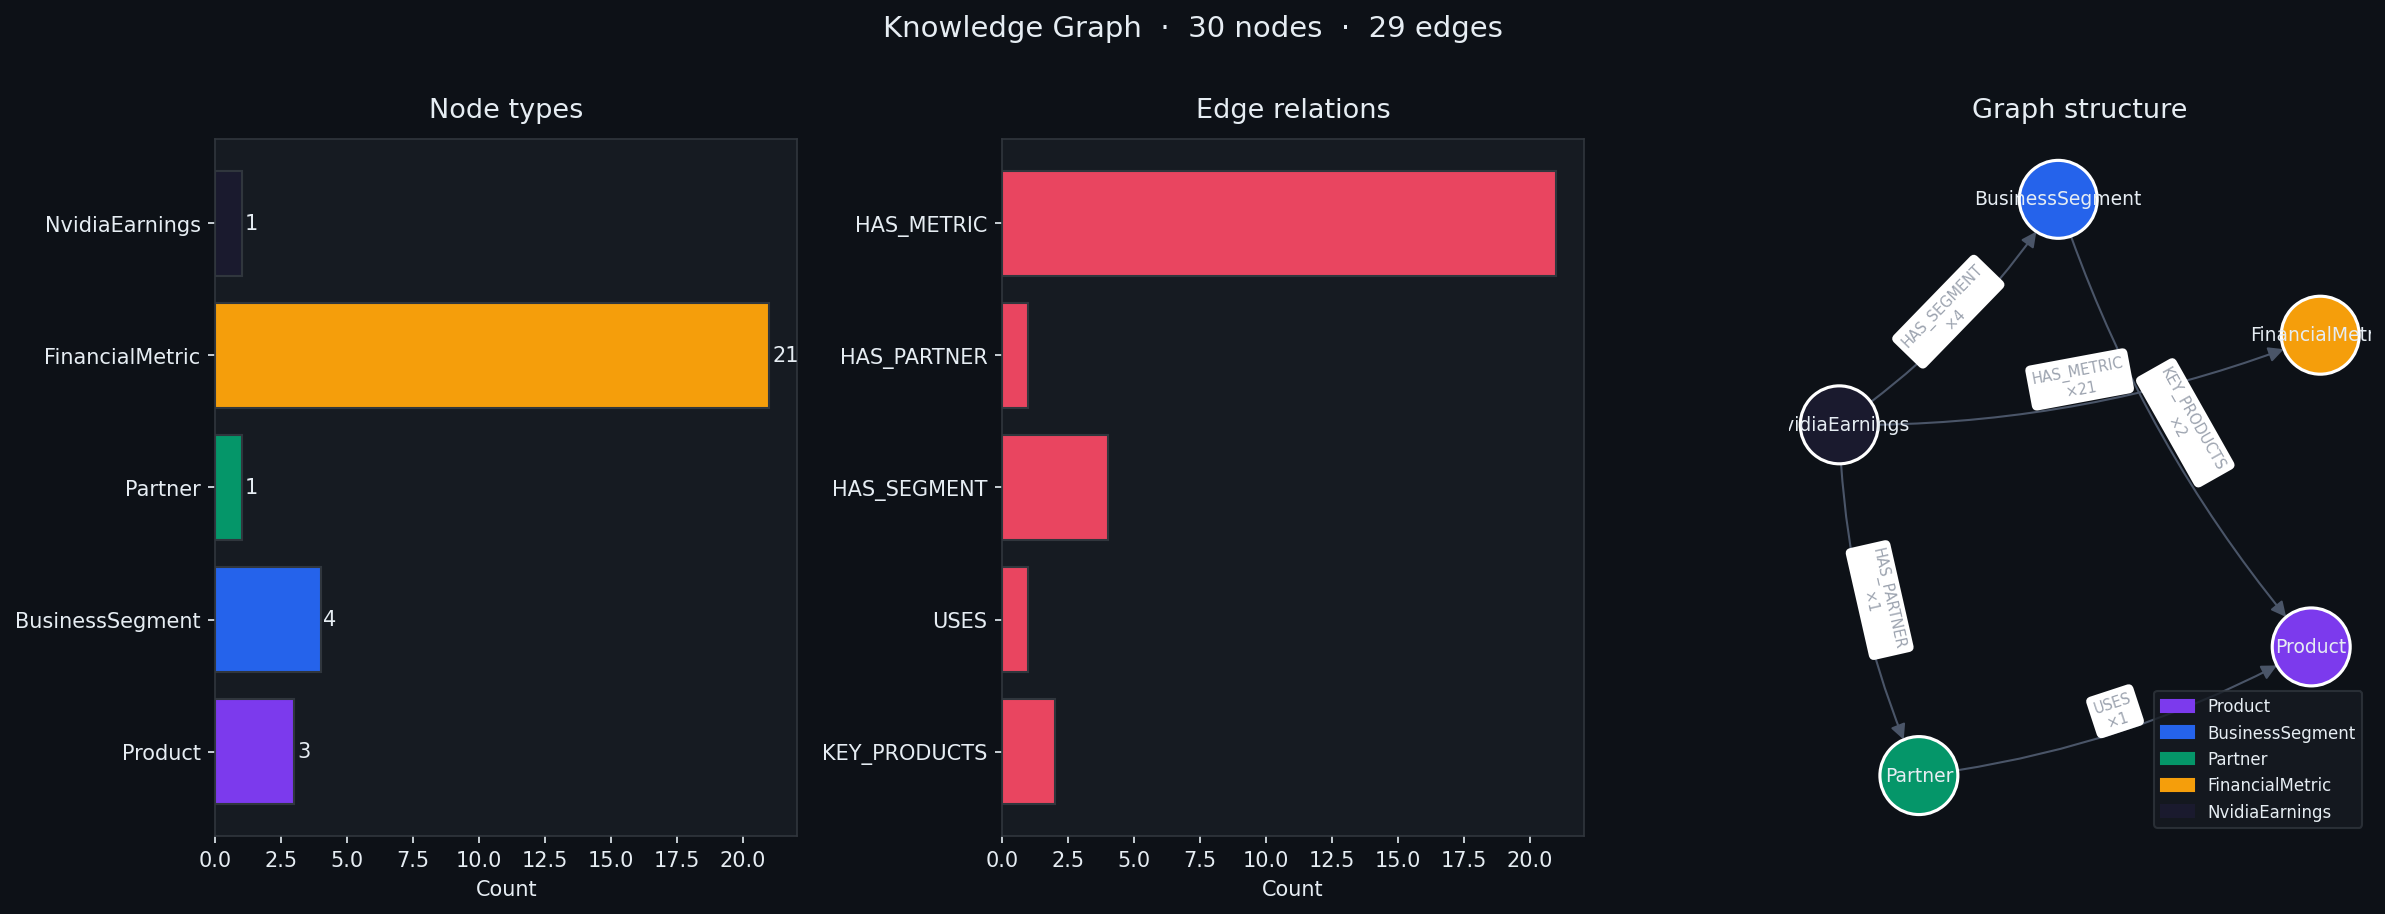

Opened in browser: /Users/krishrekapalli/dev/git/docling-graph-tutorial/data/earnings_output/graph_pretty.html


In [47]:
# Show summary chart inline; open the interactive graph in the default browser
import webbrowser
from IPython.display import Image, display

# Static summary chart — renders inline in VS Code
png_path = out_path.with_suffix(".png")
if png_path.exists():
    display(Image(str(png_path), width=700))
else:
    print("Summary chart not available — interactive graph opened in browser instead.")

# Interactive graph — opens in default system browser
webbrowser.open(out_path.as_uri())
print(f"Opened in browser: {out_path}")


---
## What's Next

In `03_advanced.ipynb` we cover production reality — when to use local vs remote,  
chunking strategy, and the Neo4j export path.

**The pattern you've now seen twice:**  
> Define entities as Pydantic models.  
> Add `List[OtherModel]` fields to create graph edges.  
> Add `graph_id_fields` to deduplicate across chunks.  
> `run_pipeline(config)` builds the graph.  
> Query with Python — no query language needed.